# MRI → Radiology Report Generation
**Task**: Given a patient's FLAIR MRI volume → generate a free-text radiology report  
**Input**: Patient-level (aggregate slices across the full volume)  
**Decoder**: Transformer decoder with beam search  
**Metrics**: BLEU-1, BLEU-2, BLEU (corpus), ROUGE-1, ROUGE-2, ROUGE-L

In [1]:
!pip install -q monai nibabel transformers rouge-score nltk scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.6 MB/s eta 0:00:00


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

from transformers import CLIPVisionModel, AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from skimage.transform import resize
from pathlib import Path

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

warnings.filterwarnings('ignore')

In [3]:
# ── Config ─────────────────────────────────────────────────────────────────
import os, torch

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Paths
if os.path.exists('/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'):
    FLAIR_DATA_PATH = '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
else:
    FLAIR_DATA_PATH = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

if os.path.exists('/kaggle/input/textbrats/TextBraTSData'):
    TEXT_DATA_PATH = '/kaggle/input/textbrats/TextBraTSData'
else:
    TEXT_DATA_PATH = '/kaggle/input/datasets/pichu99/textbrats/TextBraTSData'

OUTPUT_DIR     = '/kaggle/working/outputs'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── GPU setup — single GPU ─────────────────────────────────────────────────
# DataParallel was removed: it replicates all 118M params to GPU 1 on every
# forward pass (~450 MB overhead/step), which caused OOM after epoch 1.
# One T4 (15.6 GB) is sufficient — CLIP chunking caps peak VRAM at ~3 GB.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# ── Hyper-parameters ───────────────────────────────────────────────────────
IMAGE_SIZE    = 224
MAX_TEXT_LEN  = 128
NUM_SLICES    = 16       # informative axial slices per patient
CLIP_CHUNK    = 8        # slices processed by CLIP at once — caps peak VRAM at ~640 MB

D_MODEL       = 768      # matches CLIP ViT-B/16
N_HEADS       = 8
N_DEC_LAYERS  = 4
DIM_FF        = 2048
DROPOUT       = 0.1

BEAM_SIZE     = 4
BATCH_SIZE    = 4        # 4 patients × 16 slices per step
NUM_EPOCHS    = 100
WARMUP_EPOCHS = 3
LR            = 1e-4

SEED = 42


Device: cuda  |  Tesla T4


## 1. Vocabulary

In [4]:
class SimpleVocab:
    """Character-level token vocabulary built from training reports."""
    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self._next = 4

    def add_text(self, text: str):
        for word in text.lower().split():
            if word not in self.word2idx:
                self.word2idx[word] = self._next
                self.idx2word[self._next] = word
                self._next += 1

    def encode(self, text: str, max_len: int) -> torch.Tensor:
        ids = [self.word2idx.get(w, self.UNK) for w in text.lower().split()]
        ids = [self.SOS] + ids[: max_len - 2] + [self.EOS]
        ids += [self.PAD] * (max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def decode(self, ids) -> str:
        words = []
        for i in ids:
            tok = self.idx2word.get(int(i), '<UNK>')
            if tok == '<EOS>': break
            if tok not in ('<PAD>', '<SOS>'): words.append(tok)
        return ' '.join(words)

    @property
    def size(self):
        return self._next

vocab = SimpleVocab()

## 2. Data: Patient-Level Dataset

Each sample is **one patient**. We load the full FLAIR volume, pick `NUM_SLICES` axial slices that contain the most signal (informed sampling, not random), stack them, and pair with the patient's reference report.

In [5]:
def discover_patients():
    """Return list of dicts {patient_id, flair_path, text} for all patients
    that have both a FLAIR volume and a text report."""
    patients = []
    flair_root = Path(FLAIR_DATA_PATH)
    text_root  = Path(TEXT_DATA_PATH)

    if not flair_root.exists():
        print(f'ERROR: FLAIR path missing: {flair_root}'); return patients
    if not text_root.exists():
        print(f'ERROR: Text path missing: {text_root}');  return patients

    for p_dir in sorted(d for d in flair_root.iterdir() if d.is_dir()):
        pid = p_dir.name
        # Find FLAIR volume
        flair = p_dir / f'{pid}_flair.nii'
        if not flair.exists(): flair = p_dir / f'{pid}_flair.nii.gz'
        if not flair.exists(): continue

        # Find text report (try several naming conventions)
        txt_file = None
        for candidate in [
            text_root / pid / f'{pid}_flair_text.txt',
            text_root / f'{pid}.txt',
            text_root / pid / f'{pid}.txt',
        ]:
            if candidate.exists():
                txt_file = candidate; break
        if txt_file is None: continue

        text = txt_file.read_text().strip()
        if not text: continue

        patients.append({'patient_id': pid, 'flair_path': str(flair), 'text': text})

    print(f'Found {len(patients)} patients with FLAIR + text report')
    return patients


all_patients = discover_patients()

# Build vocab from all report text before splitting
for p in all_patients:
    vocab.add_text(p['text'])
print(f'Vocabulary size: {vocab.size}')

# 80 / 10 / 10 split at patient level
train_p, temp_p = train_test_split(all_patients, test_size=0.20, random_state=SEED)
val_p,   test_p = train_test_split(temp_p,       test_size=0.50, random_state=SEED)
print(f'Split → train:{len(train_p)}  val:{len(val_p)}  test:{len(test_p)}')

Found 369 patients with FLAIR + text report
Vocabulary size: 1007
Split → train:295  val:37  test:37


In [6]:
def load_patient_slices(flair_path: str, n_slices: int = NUM_SLICES,
                        img_size: int = IMAGE_SIZE) -> np.ndarray:
    """
    Load FLAIR volume, pick the `n_slices` most informative axial slices
    (ranked by mean absolute intensity after normalisation — proxy for
    tumour-containing slices), resize each to img_size × img_size,
    and stack as (n_slices, 3, img_size, img_size) — RGB-replicated for
    CLIP compatibility.

    Using the full volume rather than a single slice gives the model
    spatial context across the tumour's extent, which is essential for
    generating patient-level reports.
    """
    vol = nib.load(flair_path).get_fdata()            # (H, W, D)

    # Z-score normalise using the non-zero brain mask
    brain_mask = vol > 0
    if brain_mask.sum() > 0:
        mu, sigma = vol[brain_mask].mean(), vol[brain_mask].std() + 1e-8
        vol = (vol - mu) / sigma
        vol[~brain_mask] = 0.0

    # Score each axial slice by mean absolute value (high → informative)
    scores = np.abs(vol).mean(axis=(0, 1))            # (D,)
    # Pick evenly-spaced top-n_slices (preserves spatial order)
    ranked = np.argsort(scores)[::-1][:n_slices]
    ranked = sorted(ranked.tolist())                  # restore axial order

    frames = []
    for z in ranked:
        sl = vol[:, :, z]                             # (H, W)
        sl = resize(sl, (img_size, img_size),
                    anti_aliasing=True).astype(np.float32)
        # Clip and rescale to [0, 1]
        sl = np.clip(sl, -3, 3)
        sl = (sl + 3) / 6.0
        # Replicate to 3 channels for CLIP ViT input
        sl = np.stack([sl, sl, sl], axis=0)           # (3, H, W)
        frames.append(sl)

    return np.stack(frames, axis=0)                   # (n_slices, 3, H, W)


class PatientReportDataset(Dataset):
    """
    One item = one patient.
    Returns:
        slices      : (NUM_SLICES, 3, IMAGE_SIZE, IMAGE_SIZE) float32
        text_tokens : (MAX_TEXT_LEN,) long  – encoded target report
        raw_text    : str                    – reference report for metric eval
    """
    def __init__(self, patient_list: list, augment: bool = False):
        self.patients = patient_list
        self.augment  = augment

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        p = self.patients[idx]
        slices = load_patient_slices(p['flair_path'])   # (N, 3, H, W)

        if self.augment:
            # Horizontal flip with p=0.5 applied consistently across all slices
            if np.random.rand() > 0.5:
                slices = slices[:, :, :, ::-1].copy()

        tokens = vocab.encode(p['text'], MAX_TEXT_LEN)  # (MAX_TEXT_LEN,)
        return {
            'slices'     : torch.tensor(slices, dtype=torch.float32),
            'text_tokens': tokens,
            'raw_text'   : p['text'],
        }


train_dataset = PatientReportDataset(train_p, augment=True)
val_dataset   = PatientReportDataset(val_p,   augment=False)
test_dataset  = PatientReportDataset(test_p,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Loaders ready — train batches:{len(train_loader)}  '
      f'val:{len(val_loader)}  test:{len(test_loader)}')

Loaders ready — train batches:74  val:10  test:37


## 3. Model Architecture

```
Patient Volume (NUM_SLICES × 3 × 224 × 224)
        │
        ▼  shared CLIP ViT-B/16 (per slice)
Patch features  (NUM_SLICES × 196 × 768)
        │
        ▼  SlicePooling — learned weighted average across slices
Volume memory   (196 × 768)   ← one compact representation per patient
        │
        ▼  Transformer Decoder (4 layers, 8 heads)
           — attends to volume memory at every decoding step
           — causal self-attention on previously generated tokens
        │
        ▼  Linear → vocab logits
Generated report tokens  →  decode to text
```

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""
    def __init__(self, d_model: int, max_len: int = 256, dropout: float = 0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(x + self.pe[:, :x.size(1)])


class SliceAttentionPooling(nn.Module):
    """
    Aggregate NUM_SLICES patch tensors into one volume-level memory
    using a learned attention score per slice.

    Input : (B, N_slices, 196, 768)
    Output: (B, 196, 768)

    Why attention pooling instead of mean?
    Not all slices are equally informative. Slices at the tumour core
    should dominate the report. The model learns this from text supervision.
    """
    def __init__(self, d_model: int = D_MODEL):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patch_mean = x.mean(dim=2)                       # (B, N, d)
        weights    = torch.softmax(self.score(patch_mean), dim=1)  # (B, N, 1)
        return (weights.unsqueeze(2) * x).sum(dim=1)     # (B, 196, d)


class MRIReportGenerator(nn.Module):
    """
    Patient-level MRI → radiology report generator.

    Vision encoder : CLIP ViT-B/16 (frozen during warmup, unfrozen after)
    Slice pooling  : SliceAttentionPooling — learned weighted average over slices
    Text decoder   : Transformer decoder (causal) attending to volume memory

    Note: beam_search must be called on the model directly (not wrapped).
    get_core_model() is a passthrough here (kept for API consistency).
    """
    def __init__(self, vocab_size: int):
        super().__init__()
        from transformers import CLIPVisionModel

        # ── Vision encoder ────────────────────────────────────────────────
        self.vision = CLIPVisionModel.from_pretrained(
            'openai/clip-vit-base-patch16',
            output_hidden_states=True,
            return_dict=True,
        )
        for p in self.vision.parameters():
            p.requires_grad = False          # frozen initially

        # ── Slice aggregation ─────────────────────────────────────────────
        self.slice_pool = SliceAttentionPooling(D_MODEL)

        # ── Text decoder ──────────────────────────────────────────────────
        self.embed   = nn.Embedding(vocab_size, D_MODEL, padding_idx=SimpleVocab.PAD)
        self.pos_enc = PositionalEncoding(D_MODEL, max_len=MAX_TEXT_LEN + 10,
                                          dropout=DROPOUT)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=D_MODEL, nhead=N_HEADS,
            dim_feedforward=DIM_FF, dropout=DROPOUT, batch_first=True,
        )
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=N_DEC_LAYERS)
        self.proj     = nn.Linear(D_MODEL, vocab_size)
        self.proj.weight = self.embed.weight   # weight tying
        self.mem_norm = nn.LayerNorm(D_MODEL)

    # ── Encoder — called inside forward (parallelisable) ──────────────────
    def encode_volume(self, slices: torch.Tensor,
                      chunk_size: int = CLIP_CHUNK) -> torch.Tensor:
        """
        Encode a patient volume through CLIP ViT in small chunks to
        avoid OOM from passing all B*N slices at once.

        Root cause of OOM: CLIP MLP layers expand each token from 768 to
        3072 dims. With 80 images (4 patients × 20 slices) per GPU,
        peak activation memory is ~6 GB — filling both T4s.

        Fix: process `chunk_size` slices at a time, accumulate patch
        features, then pool. Peak VRAM = chunk_size × ~80 MB ≈ 640 MB
        for chunk_size=8, regardless of batch size or NUM_SLICES.

        Args:
            slices    : (B, N_slices, 3, H, W)
            chunk_size: number of slices processed by CLIP at once
        Returns:
            memory    : (B, 196, D_MODEL)
        """
        B, N, C, H, W = slices.shape
        flat = slices.view(B * N, C, H, W)   # (B*N, 3, H, W)

        all_patches = []
        for i in range(0, B * N, chunk_size):
            chunk = flat[i : i + chunk_size]          # (≤chunk_size, 3, H, W)
            v_out = self.vision(pixel_values=chunk)
            # Drop CLS token, keep patch tokens
            all_patches.append(v_out.last_hidden_state[:, 1:, :])  # (chunk, 196, 768)

        patches = torch.cat(all_patches, dim=0)       # (B*N, 196, 768)
        patches = patches.view(B, N, 196, D_MODEL)    # (B, N, 196, 768)
        return self.mem_norm(self.slice_pool(patches)) # (B, 196, 768)

    # ── Teacher-forced forward (training) ─────────────────────────────────
    def forward(self, slices: torch.Tensor,
                target_tokens: torch.Tensor) -> torch.Tensor:
        """
        Args:
            slices        : (B, N_slices, 3, H, W)
            target_tokens : (B, MAX_TEXT_LEN)
        Returns:
            logits        : (B, L-1, vocab_size)
        """
        memory  = self.encode_volume(slices)             # (B, 196, D)
        dec_in  = target_tokens[:, :-1]                  # (B, L-1)
        L       = dec_in.size(1)
        tgt_emb = self.pos_enc(self.embed(dec_in))       # (B, L-1, D)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            L, device=slices.device)
        pad_mask    = (dec_in == SimpleVocab.PAD)
        dec_out = self.decoder(
            tgt=tgt_emb, memory=memory,
            tgt_mask=causal_mask, tgt_key_padding_mask=pad_mask,
        )
        return self.proj(dec_out)                        # (B, L-1, vocab_size)

    # ── Beam search (inference, B=1 only) ────────────────────────────────
    @torch.no_grad()
    def beam_search(self, slices: torch.Tensor,
                    beam_size: int = BEAM_SIZE,
                    max_len:   int = MAX_TEXT_LEN) -> list:
        """
        Beam search decoding for a single patient (B=1).

        Length normalisation: log_prob / length prevents preference for
        short sequences.
        """
        assert slices.size(0) == 1, 'beam_search: B must be 1'
        self.eval()
        memory = self.encode_volume(slices)              # (1, 196, D)
        beams, completed = [(0.0, [SimpleVocab.SOS])], []

        for _ in range(max_len):
            if not beams: break
            all_cands = []
            for log_prob, ids in beams:
                if ids[-1] == SimpleVocab.EOS:
                    completed.append((log_prob / len(ids), ids)); continue
                seq    = torch.tensor([ids], dtype=torch.long, device=slices.device)
                emb    = self.pos_enc(self.embed(seq))
                L      = seq.size(1)
                causal = nn.Transformer.generate_square_subsequent_mask(
                    L, device=slices.device)
                out    = self.decoder(emb, memory, tgt_mask=causal)
                lps    = F.log_softmax(self.proj(out[:, -1, :]), dim=-1)[0]
                topk_lp, topk_ids = lps.topk(beam_size)
                for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                    all_cands.append((log_prob + lp, ids + [tid]))
            all_cands.sort(key=lambda x: x[0], reverse=True)
            beams = all_cands[:beam_size]

        if not completed:
            completed = [(lp / len(ids), ids) for lp, ids in beams]
        completed.sort(key=lambda x: x[0], reverse=True)
        return completed[0][1]


# ── Instantiate model (single GPU) ───────────────────────────────────────
model = MRIReportGenerator(vocab_size=vocab.size).to(device)

def get_core_model(m):
    """Passthrough helper — used by beam_search and checkpoint saving."""
    return m

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device        : {device}")
print(f"Total params  : {total_p/1e6:.2f}M")
print(f"Trainable     : {trainable_p/1e6:.2f}M  (vision frozen at init)")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weigh

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Device        : cuda
Total params  : 118.09M
Trainable     : 32.29M  (vision frozen at init)


## 4. Loss Function

Pure text generation — only cross-entropy on generated tokens. PAD tokens are ignored.

In [8]:
ce_loss = nn.CrossEntropyLoss(ignore_index=SimpleVocab.PAD)

## 5. Evaluation Metrics

| Metric | What it measures |
|---|---|
| BLEU-1 | Unigram precision — individual word accuracy |
| BLEU-2 | Bigram precision — short phrase accuracy |
| BLEU (corpus) | 4-gram with brevity penalty — overall fluency |
| ROUGE-1 | Unigram recall/F1 — word coverage |
| ROUGE-2 | Bigram recall/F1 — phrase coverage |
| ROUGE-L | Longest common subsequence — sentence-level structure |

In [9]:
def compute_all_metrics(model: nn.Module,
                        loader,
                        device: torch.device,
                        beam_size: int = BEAM_SIZE) -> dict:
    """
    Run beam search on every patient and compute all 6 text metrics.

    Calls beam_search on get_core_model(model) — single GPU inference.
    """
    core = get_core_model(model)
    core.eval()

    r_scorer  = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'],
                                         use_stemmer=True)
    all_refs, all_hyps             = [], []
    r1_scores, r2_scores, rL_scores = [], [], []

    with torch.no_grad():
        for batch in loader:
            slices   = batch['slices']
            raw_text = batch['raw_text']

            for b in range(slices.size(0)):
                s_b     = slices[b].unsqueeze(0).to(device)  # (1, N, 3, H, W)
                gen_ids  = core.beam_search(s_b, beam_size=beam_size)
                gen_text = vocab.decode(gen_ids)
                ref_text = raw_text[b]

                all_refs.append([ref_text.lower().split()])
                all_hyps.append(gen_text.split())

                scores = r_scorer.score(ref_text, gen_text)
                r1_scores.append(scores['rouge1'].fmeasure)
                r2_scores.append(scores['rouge2'].fmeasure)
                rL_scores.append(scores['rougeL'].fmeasure)

    return {
        'bleu1' : corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0)),
        'bleu2' : corpus_bleu(all_refs, all_hyps, weights=(0.5, 0.5, 0, 0)),
        'bleu'  : corpus_bleu(all_refs, all_hyps),
        'rouge1': float(np.mean(r1_scores)),
        'rouge2': float(np.mean(r2_scores)),
        'rougeL': float(np.mean(rL_scores)),
    }


## 6. Training

In [10]:
def train_epoch(model: nn.Module,
                loader,
                optimiser: torch.optim.Optimizer,
                scaler: GradScaler,
                scheduler,
                device: torch.device) -> float:
    """
    One training epoch (teacher-forced cross-entropy).

    Single GPU, teacher-forced cross-entropy.
    """
    model.train()
    total_loss = 0.0
    torch.cuda.empty_cache()  # release any lingering cached tensors before epoch

    for batch in loader:
        slices  = batch['slices'].to(device)        # (B, N, 3, H, W)
        tokens  = batch['text_tokens'].to(device)   # (B, MAX_TEXT_LEN)

        optimiser.zero_grad()
        with autocast():
            logits  = model(slices, tokens)           # (B, L-1, vocab_size)
            targets = tokens[:, 1:]                   # (B, L-1)
            loss    = ce_loss(
                logits.reshape(-1, vocab.size),
                targets.reshape(-1),
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def val_loss_fn(model: nn.Module, loader, device: torch.device) -> float:
    """Teacher-forced validation loss (fast, no beam search)."""
    model.eval()
    total = 0.0
    for batch in loader:
        slices  = batch['slices'].to(device)
        tokens  = batch['text_tokens'].to(device)
        with autocast():
            logits  = model(slices, tokens)
            targets = tokens[:, 1:]
            total  += ce_loss(logits.reshape(-1, vocab.size),
                              targets.reshape(-1)).item()
    return total / len(loader)


In [11]:
from torch.cuda.amp import GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

optimiser = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler    = GradScaler()

total_steps  = NUM_EPOCHS    * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

scheduler = SequentialLR(
    optimiser,
    schedulers=[
        LinearLR(optimiser, start_factor=0.1, end_factor=1.0,
                 total_iters=warmup_steps),
        CosineAnnealingLR(optimiser,
                          T_max=max(1, total_steps - warmup_steps),
                          eta_min=1e-6),
    ],
    milestones=[warmup_steps],
)

history = {
    'train_loss': [], 'val_loss': [],
    'bleu1': [], 'bleu2': [], 'bleu': [],
    'rouge1': [], 'rouge2': [], 'rougeL': [],
}
best_rougeL       = 0.0
best_ckpt         = f'{CHECKPOINT_DIR}/best_model.pt'
METRIC_EVAL_FREQ  = 3   # beam search every N epochs (slow)

print('\n' + '='*65)
print('  MRI → Report Generation  |  Single GPU')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Unfreeze vision encoder after warmup ──────────────────────────────
    # Always access vision through the unwrapped model (get_core_model),
    # then optimizer already tracks those parameters.
    if epoch == WARMUP_EPOCHS + 1:
        print('\n>> Unfreezing CLIP vision encoder')
        for p in get_core_model(model).vision.parameters():
            p.requires_grad = True
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'   Trainable params now: {trainable/1e6:.2f}M')
        # Rebuild optimiser to include newly unfrozen params
        optimiser = AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=LR / 10,          # lower LR for fine-tuning vision encoder
            weight_decay=1e-4,
        )

    t_loss = train_epoch(model, train_loader, optimiser, scaler, scheduler, device)
    v_loss = val_loss_fn(model, val_loader, device)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  ' +
          f'train={t_loss:.4f}  val={v_loss:.4f}', end='')

    if epoch % METRIC_EVAL_FREQ == 0 or epoch == NUM_EPOCHS:
        metrics = compute_all_metrics(model, val_loader, device)
        for k, v in metrics.items():
            history[k].append(v)

        print(f'\n   BLEU-1={metrics["bleu1"]:.4f}  '
              f'BLEU-2={metrics["bleu2"]:.4f}  '
              f'BLEU-4={metrics["bleu"]:.4f}')
        print(f'   ROUGE-1={metrics["rouge1"]:.4f}  '
              f'ROUGE-2={metrics["rouge2"]:.4f}  '
              f'ROUGE-L={metrics["rougeL"]:.4f}')

        if metrics['rougeL'] > best_rougeL:
            best_rougeL = metrics['rougeL']
            torch.save({
                'epoch'      : epoch,
                'model_state': get_core_model(model).state_dict(),
                'metrics'    : metrics,
                'vocab_size' : vocab.size,
            }, best_ckpt)
            print(f'   ✓ Best model saved  (val ROUGE-L={best_rougeL:.4f})')
    else:
        print()



  MRI → Report Generation  |  Single GPU
Epoch 01/100  train=57.9560  val=11.2852
Epoch 02/100  train=15.2239  val=8.7668
Epoch 03/100  train=11.8865  val=7.7991
   BLEU-1=0.1037  BLEU-2=0.0750  BLEU-4=0.0492
   ROUGE-1=0.1184  ROUGE-2=0.0624  ROUGE-L=0.1169
   ✓ Best model saved  (val ROUGE-L=0.1169)

>> Unfreezing CLIP vision encoder
   Trainable params now: 118.09M
Epoch 04/100  train=9.3021  val=5.5436
Epoch 05/100  train=8.5841  val=5.2449
Epoch 06/100  train=8.1567  val=5.0740
   BLEU-1=0.1972  BLEU-2=0.1493  BLEU-4=0.0900
   ROUGE-1=0.2602  ROUGE-2=0.1575  ROUGE-L=0.2117
   ✓ Best model saved  (val ROUGE-L=0.2117)
Epoch 07/100  train=7.8256  val=5.0627
Epoch 08/100  train=7.5560  val=4.9553
Epoch 09/100  train=7.2913  val=4.8131
   BLEU-1=0.2856  BLEU-2=0.2078  BLEU-4=0.1201
   ROUGE-1=0.3774  ROUGE-2=0.1998  ROUGE-L=0.3015
   ✓ Best model saved  (val ROUGE-L=0.3015)
Epoch 10/100  train=7.0264  val=4.7030
Epoch 11/100  train=6.8538  val=4.4850
Epoch 12/100  train=6.6437  val=4.

## 7. Final Test Evaluation

In [12]:
# Load best checkpoint into the unwrapped model, then re-wrap if needed
ckpt = torch.load(best_ckpt, map_location=device)
get_core_model(model).load_state_dict(ckpt['model_state'])
print(f'Loaded best model from epoch {ckpt["epoch"]}  '
      f'(val ROUGE-L={ckpt["metrics"]["rougeL"]:.4f})')

print('\nRunning final test evaluation (beam search)...')
test_metrics = compute_all_metrics(model, test_loader, device, beam_size=BEAM_SIZE)

print('\n' + '='*55)
print('  TEST SET RESULTS')
print('='*55)
print(f'  BLEU-1  : {test_metrics["bleu1"]:.4f}')
print(f'  BLEU-2  : {test_metrics["bleu2"]:.4f}')
print(f'  BLEU-4  : {test_metrics["bleu"]:.4f}   (4-gram corpus)')
print(f'  ROUGE-1 : {test_metrics["rouge1"]:.4f}')
print(f'  ROUGE-2 : {test_metrics["rouge2"]:.4f}')
print(f'  ROUGE-L : {test_metrics["rougeL"]:.4f}')
print('='*55)


Loaded best model from epoch 93  (val ROUGE-L=0.4845)

Running final test evaluation (beam search)...

  TEST SET RESULTS
  BLEU-1  : 0.5323
  BLEU-2  : 0.3929
  BLEU-4  : 0.2201   (4-gram corpus)
  ROUGE-1 : 0.6179
  ROUGE-2 : 0.3469
  ROUGE-L : 0.4775


## 8. Qualitative Sample Output

In [13]:
def show_sample_reports(model, dataset, device, n=5):
    """Display generated vs reference reports for n random test patients."""
    core = get_core_model(model)
    core.eval()
    r_scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
    indices  = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    for i, idx in enumerate(indices):
        sample  = dataset[idx]
        slices  = sample['slices'].unsqueeze(0).to(device)
        ref     = sample['raw_text']
        gen_ids = core.beam_search(slices, beam_size=BEAM_SIZE)
        gen     = vocab.decode(gen_ids)
        bleu1   = corpus_bleu([[ref.lower().split()]], [gen.split()],
                               weights=(1,0,0,0))
        scores  = r_scorer.score(ref, gen)
        print(f'\n──── Patient {i+1} ' + '─'*45)
        print(f'REFERENCE : {ref}')
        print(f'GENERATED : {gen}')
        print(f'BLEU-1={bleu1:.3f}  '
              f'R1={scores["rouge1"].fmeasure:.3f}  '
              f'R2={scores["rouge2"].fmeasure:.3f}  '
              f'RL={scores["rougeL"].fmeasure:.3f}')

show_sample_reports(model, test_dataset, device, n=5)



──── Patient 1 ─────────────────────────────────────────────
REFERENCE : The lesion area is in the right frontal and parietal lobes with a mixture of heterogeneous signal intensities and spotted high-signal areas. Edema is significant, particularly in the right parietal lobe, extensive and affects the surrounding brain tissue. Necrosis is in the right frontal lobe, low-signal areas interspersed with high-signal areas. Ventricular compression is significant, especially on the right side.
GENERATED : the lesion area is in the right cerebral hemisphere, particularly in the frontal and parietal lobes, with a mix of heterogeneous high and low signals. edema is mainly concentrated in the right temporal and parietal lobes, with a high signal areas of the surrounding normal brain tissue. necrosis is mainly concentrated in the right temporal lobe, with low signal areas with a high signal areas of ventricular compression is observed with the right ventricle compressed and deformed, resulting in

## 9. Training Curves

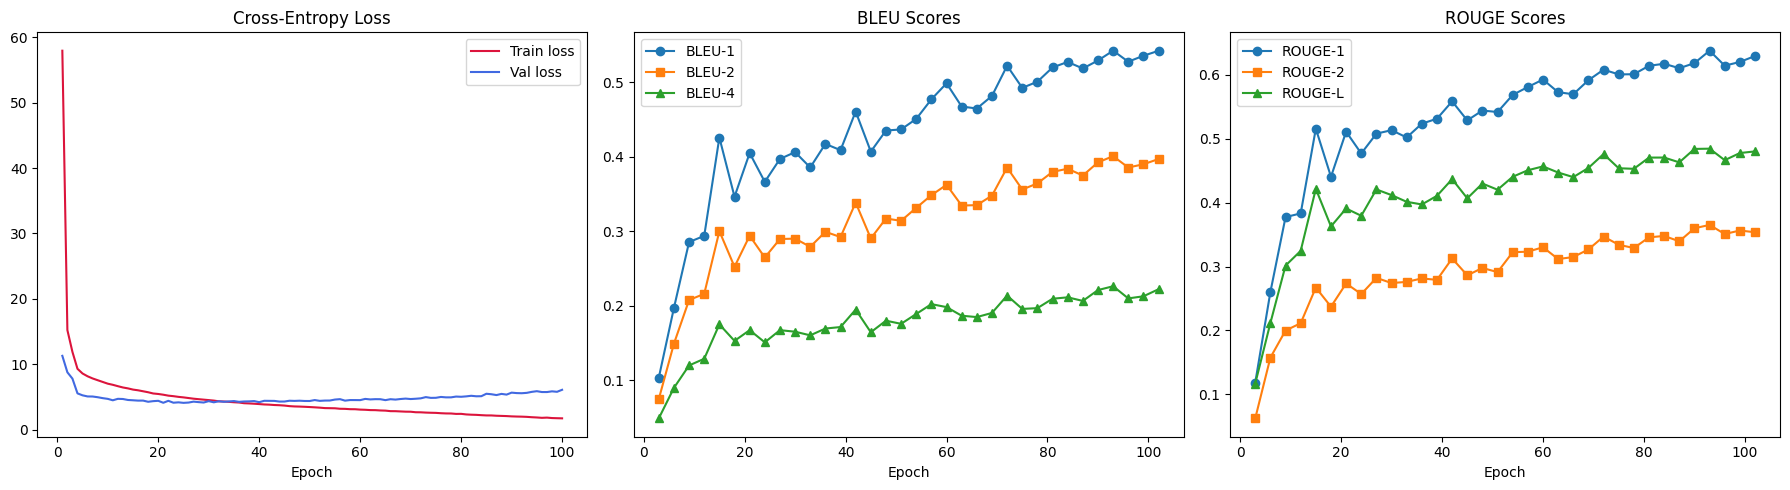

Saved training curves.


In [14]:
def plot_training_curves(history: dict):
    epochs_all    = range(1, len(history['train_loss']) + 1)
    epochs_metric = range(METRIC_EVAL_FREQ,
                          METRIC_EVAL_FREQ * len(history['bleu1']) + 1,
                          METRIC_EVAL_FREQ)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(epochs_all, history['train_loss'], label='Train loss', color='crimson')
    axes[0].plot(epochs_all, history['val_loss'],   label='Val loss',   color='royalblue')
    axes[0].set_title('Cross-Entropy Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

    # BLEU curves
    axes[1].plot(epochs_metric, history['bleu1'], label='BLEU-1', marker='o')
    axes[1].plot(epochs_metric, history['bleu2'], label='BLEU-2', marker='s')
    axes[1].plot(epochs_metric, history['bleu'],  label='BLEU-4', marker='^')
    axes[1].set_title('BLEU Scores'); axes[1].legend(); axes[1].set_xlabel('Epoch')

    # ROUGE curves
    axes[2].plot(epochs_metric, history['rouge1'], label='ROUGE-1', marker='o')
    axes[2].plot(epochs_metric, history['rouge2'], label='ROUGE-2', marker='s')
    axes[2].plot(epochs_metric, history['rougeL'], label='ROUGE-L', marker='^')
    axes[2].set_title('ROUGE Scores'); axes[2].legend(); axes[2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
    plt.show()
    print('Saved training curves.')


plot_training_curves(history)